In [100]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("abhi8923shriv/sentiment-analysis-dataset")

# print("Path to dataset files:", path)

[Link ke dataset](https://www.kaggle.com/datasets/abhi8923shriv/sentiment-analysis-dataset/code)

In [101]:
import pandas as pd

In [102]:

path = r'sentiment_data\train.csv'
data_train = pd.read_csv(path, encoding='latin-1')

data_train.head()

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


In [103]:

path_2 = r'sentiment_data\test.csv'
data_test = pd.read_csv(path_2, encoding='latin-1')

data_test.head()

,textID,text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,f87dea47db,Last session of the day http://twitpic.com/67ezh,neutral,morning,0-20,Afghanistan,38928346.0,652860.0,60.0
1,96d74cb729,Shanghai is also really exciting (precisely -...,positive,noon,21-30,Albania,2877797.0,27400.0,105.0
2,eee518ae67,"Recession hit Veronique Branquinho, she has to...",negative,night,31-45,Algeria,43851044.0,2381740.0,18.0
3,01082688c6,happy bday!,positive,morning,46-60,Andorra,77265.0,470.0,164.0
4,33987a8ee5,http://twitpic.com/4w75p - I like it!!,positive,noon,60-70,Angola,32866272.0,1246700.0,26.0


In [104]:
# Ambil kolom text dan sentiment saja
train_df = data_train[['text', 'sentiment']]
test_df = data_test[['text', 'sentiment']]

# Pastikan tidak ada nilai kosong (NaN) agar tidak error saat preprocessing
train_df = train_df.dropna()
test_df = test_df.dropna()


In [105]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer  # Tambahkan import ini

# Download list stopword bahasa inggris
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Inisialisasi Porter Stemmer
stemmer = PorterStemmer()

def clean_text(text):
    # 1. Ubah ke lowercase
    text = text.lower()
    
    # 2. Hapus URL (http/https)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # 3. Hapus Mention (@user) dan Hashtag (#)
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)
    text = re.sub(r'#', '', text)
    
    # 4. Hapus tanda baca dan angka
    text = re.sub(r'[^a-z\s]', '', text)
    
    # 5. Hapus Stopwords
    words = [word for word in text.split() if word not in stop_words]
    
    # 6. Tambah Stemming Bahasa Inggris
    text = ' '.join([stemmer.stem(word) for word in words])
    
    return text

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [106]:
# Terapkan pembersihan
train_df['text_clean'] = train_df['text'].apply(clean_text)
test_df['text_clean'] = test_df['text'].apply(clean_text)

# Lihat perbandingannya
print(train_df[['text', 'text_clean']].head())


                                                text  \
0                I`d have responded, if I were going   
1      Sooo SAD I will miss you here in San Diego!!!   
2                          my boss is bullying me...   
3                     what interview! leave me alone   
4   Sons of ****, why couldn`t they put them on t...   

                              text_clean  
0                          id respond go  
1                sooo sad miss san diego  
2                             boss bulli  
3                    interview leav alon  
4  son couldnt put releas alreadi bought  


In [107]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
import pickle

# 1. Encode Sentiment (Label ke Angka)
le = LabelEncoder()
train_labels = le.fit_transform(train_df['sentiment'])
test_labels = le.transform(test_df['sentiment'])

# 2. Convert ke One-Hot (karena ada 3 kelas)
train_labels = tf.keras.utils.to_categorical(train_labels)
test_labels = tf.keras.utils.to_categorical(test_labels)

# 3. Tokenisasi Teks
vocab_size = 40000
max_length = 70
trunc_type = 'post'
padding_type = 'post'
oov_tok = "<OOV>"

tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(train_df['text_clean'])

# Ubah teks menjadi sequence angka
train_sequences = tokenizer.texts_to_sequences(train_df['text_clean'])
train_padded = pad_sequences(train_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

test_sequences = tokenizer.texts_to_sequences(test_df['text_clean'])
test_padded = pad_sequences(test_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)



# Menyimpan tokenizer ke dalam file .pickle
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)
    
print("File tokenizer.pickle berhasil disimpan!")

File tokenizer.pickle berhasil disimpan!


In [108]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Embedding, SpatialDropout1D, LSTM, Bidirectional,
    GlobalMaxPooling1D, GlobalAveragePooling1D,
    Concatenate, Dense, Dropout, LayerNormalization
)
from tensorflow.keras import regularizers

# Modifikasi Model Sequential berdasarkan referensi Baseline++
model = tf.keras.Sequential([
    # 1. Embedding dengan dimensi disesuaikan (atau gunakan 128 sesuai referensi)
    Embedding(
        input_dim=vocab_size, 
        output_dim=32, # Tetap 32 sesuai kapasitas Anda, atau ubah ke 128 sesuai referensi
        input_length=max_length,
        embeddings_regularizer=regularizers.l2(1e-4)
    ),
    
    # 2. Menambahkan SpatialDropout1D setelah Embedding
    SpatialDropout1D(0.30),
    
    # 3. Bidirectional LSTM dengan penambahan L2 regularization pada kernel & recurrent
    Bidirectional(
        LSTM(
            32, # Tetap 32 sesuai kapasitas Anda, atau ubah ke 96 sesuai referensi
            return_sequences=True,
            dropout=0.3,          
            recurrent_dropout=0.2,
            kernel_regularizer=regularizers.l2(1e-4),
            recurrent_regularizer=regularizers.l2(1e-4)
        )
    ),
    
    # 4. Menambahkan Layer Normalization setelah LSTM
    LayerNormalization(),
    
    # 5. Menggabungkan Max Pooling dan Average Pooling (Concatenate via sub-layer)
    # Catatan: Karena Sequential kaku, kita gunakan Lambda untuk concatenate hasil pooling
    tf.keras.layers.Lambda(lambda x: tf.concat([
        GlobalMaxPooling1D()(x), 
        GlobalAveragePooling1D()(x)
    ], axis=-1)),
    
    # 6. Dense Layer Utama dengan Dropout awal 30%
    Dropout(0.30),
    Dense(
        16, # Tetap 16 sesuai kapasitas Anda, atau ubah ke 128 sesuai referensi
        activation='relu',
        kernel_regularizer=regularizers.l2(1e-4)
    ),
    
    # 7. Dropout tambahan sebelum Output (20%)
    Dropout(0.220),
    
    # Output layer
    Dense(3, activation='softmax') 
])

# 8. Compile dengan tambahan Label Smoothing pada loss function
model.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.03), 
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), 
    metrics=['accuracy']
)

model.summary()


c:\ALAN\Alan\Kelas Machine Learning\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_4             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_9 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_4           │ ?                      │   0 (unbuilt) │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_4 (Lambda)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [109]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',     # Memantau kerugian pada data validasi
    patience=5,             # Berhenti jika val_loss tidak membaik selama 3 epoch
    restore_best_weights=True # Mengembalikan bobot terbaik yang pernah dicapai
)


history = model.fit(
    train_padded, 
    train_labels, 
    epochs=15,
    validation_data=(test_padded, test_labels),
    verbose=1
    # callbacks=[early_stop]
)


Epoch 1/15
859/859 ━━━━━━━━━━━━━━━━━━━━ 107s 104ms/step - accuracy: 0.5023 - loss: 1.0178 - val_accuracy: 0.7009 - val_loss: 0.7650
Epoch 2/15
859/859 ━━━━━━━━━━━━━━━━━━━━ 88s 103ms/step - accuracy: 0.7072 - loss: 0.7816 - val_accuracy: 0.7247 - val_loss: 0.7231
Epoch 3/15
859/859 ━━━━━━━━━━━━━━━━━━━━ 91s 106ms/step - accuracy: 0.7512 - loss: 0.7072 - val_accuracy: 0.7374 - val_loss: 0.7340
Epoch 4/15
859/859 ━━━━━━━━━━━━━━━━━━━━ 97s 113ms/step - accuracy: 0.7789 - loss: 0.6626 - val_accuracy: 0.7298 - val_loss: 0.7578
Epoch 5/15
859/859 ━━━━━━━━━━━━━━━━━━━━ 94s 110ms/step - accuracy: 0.7984 - loss: 0.6337 - val_accuracy: 0.7269 - val_loss: 0.7824
Epoch 6/15
859/859 ━━━━━━━━━━━━━━━━━━━━ 103s 120ms/step - accuracy: 0.8102 - loss: 0.6156 - val_accuracy: 0.7230 - val_loss: 0.8118
Epoch 7/15
859/859 ━━━━━━━━━━━━━━━━━━━━ 121s 141ms/step - accuracy: 0.8212 - loss: 0.6017 - val_accuracy: 0.7190 - val_loss: 0.8402
Epoch 8/15
859/859 ━━━━━━━━━━━━━━━━━━━━ 113s 131ms/step - accuracy: 0.8275 - los

In [110]:
model.save("Sentiment_model.h5")

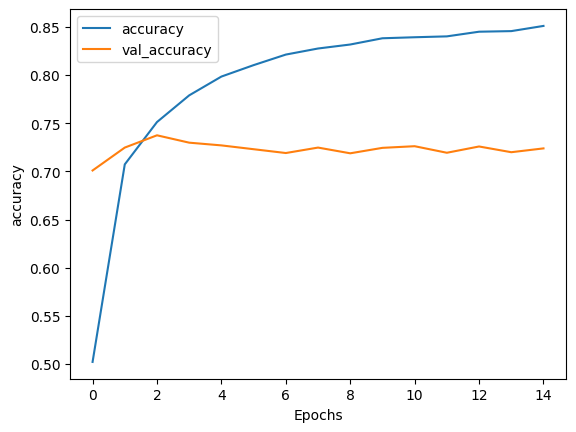

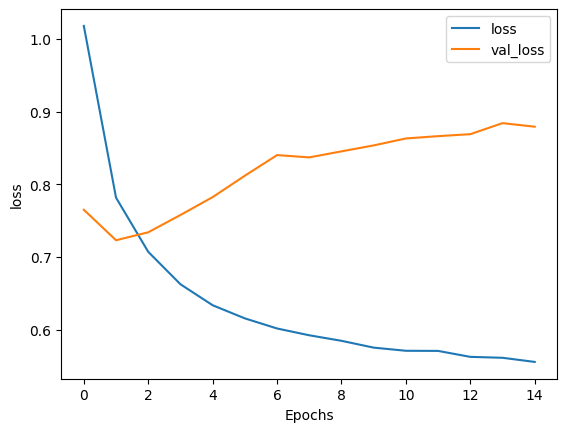

In [111]:
import matplotlib.pyplot as plt

# Buat fungsi untuk plotting
def plot_graphs(history, string):
    plt.plot(history.history[string])
    plt.plot(history.history['val_'+string])
    plt.xlabel("Epochs")
    plt.ylabel(string)
    plt.legend([string, 'val_'+string])
    plt.show()

# Tampilkan plot Akurasi
plot_graphs(history, "accuracy")

# Tampilkan plot Loss
plot_graphs(history, "loss")
